# Analyse d'un dataset sur Starcraft 2

Cette analyse explore les facteurs influençant la performance des joueurs de StarCraft II, en se concentrant sur trois dimensions principales : l’âge, le volume de pratique et la progression dans les rangs compétitifs.

## Import des librairies

In [1246]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [1247]:
df = pd.read_csv("SkillCraft.csv")
df.describe()

,GameID,LeagueIndex,Age,HoursPerWeek,TotalHours,APM,SelectByHotkeys,AssignToHotkeys,UniqueHotkeys,MinimapAttacks,MinimapRightClicks,NumberOfPACs,GapBetweenPACs,ActionLatency,ActionsInPAC,TotalMapExplored,WorkersMade,UniqueUnitsMade,ComplexUnitsMade,ComplexAbilitiesUsed
count,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000,3338.000000
mean,4719.552127,4.120731,21.650389,15.909527,960.421809,114.575763,0.004023,0.000364,4.316357,0.000094,0.000380,0.003433,40.713819,64.209584,5.266955,22.116836,0.001031,6.541043,0.000060,0.000142
std,2656.919630,1.448170,4.206357,11.964495,17318.133922,48.111912,0.004726,0.000210,2.333322,0.000159,0.000359,0.000966,17.057191,19.037394,1.500605,7.440875,0.000520,1.859049,0.000112,0.000266
min,52.000000,1.000000,16.000000,0.000000,3.000000,22.059600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000679,6.666700,24.632600,2.038900,5.000000,0.000077,2.000000,0.000000,0.000000
25%,2423.250000,3.000000,19.000000,8.000000,300.000000,79.231500,0.001245,0.000202,3.000000,0.000000,0.000139,0.002743,29.326600,50.886425,4.261525,17.000000,0.000682,5.000000,0.000000,0.000000
50%,4788.000000,4.000000,21.000000,12.000000,500.000000,107.070300,0.002445,0.000349,4.000000,0.000039,0.000278,0.003376,37.058900,61.296100,5.087050,22.000000,0.000904,6.000000,0.000000,0.000020
75%,6994.750000,5.000000,24.000000,20.000000,800.000000,140.156100,0.004945,0.000493,6.000000,0.000113,0.000508,0.004003,48.510425,74.032525,6.027350,27.000000,0.001258,8.000000,0.000087,0.000182
max,9271.000000,7.000000,44.000000,168.000000,1000000.000000,389.831400,0.043088,0.001648,10.000000,0.003019,0.003688,0.007971,237.142900,176.372100,18.558100,58.000000,0.005149,13.000000,0.000902,0.003084


## Question 1: Deviens-ton plus lent avec l'âge ? (age et apm = action par minute)

In [ ]:
# Clean dataset
clean_df = df[
    (df['HoursPerWeek'] <= 100)
]

clean_df = clean_df[["Age", "APM", "HoursPerWeek"]]

clean_df.head()

,Age,APM,HoursPerWeek
0,27,143.7180,10
1,23,129.2322,10
2,30,69.9612,10
3,19,107.6016,20
4,32,122.8908,10


<Axes: xlabel='AgeMoyen', ylabel='APM'>

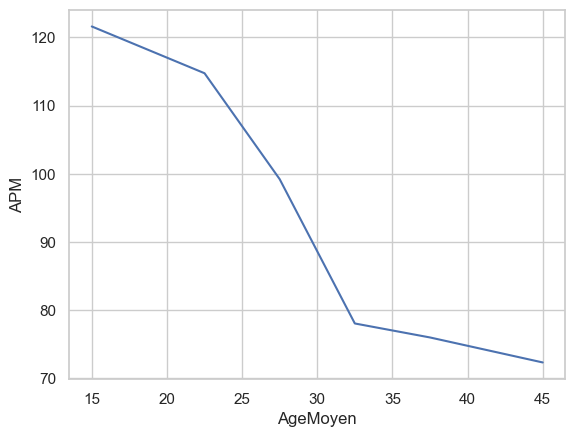

In [1249]:
clean_df['AgeBin'] = pd.cut(
    clean_df['Age'],
    bins=[10, 20, 25, 30, 35, 40, 50, 60]
)

age_speed_df = clean_df.groupby('AgeBin')['APM'].mean().reset_index()
age_speed_df['AgeMoyen'] = age_speed_df['AgeBin'].apply(lambda x: x.mid)

sns.lineplot(age_speed_df, x = "AgeMoyen", y = "APM")


La tendance montre que les personnes plus âgées sont plus lentes.
Cependant, le graphique ci-dessous montre que les personnes plus âgées passent moins de temps sur le jeu par semaine.

<Axes: xlabel='AgeMoyen', ylabel='HoursPerWeek'>

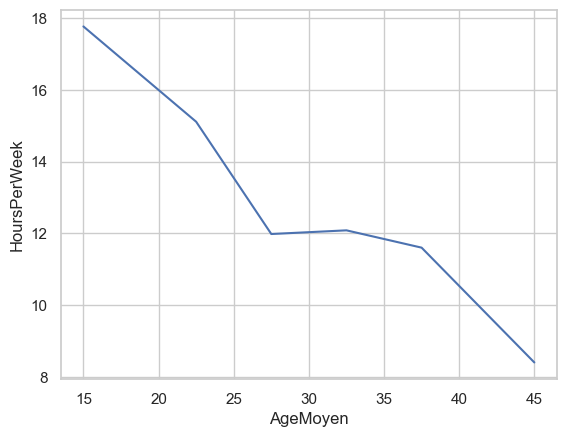

In [1250]:
age_hoursweek_df = clean_df.groupby('AgeBin')['HoursPerWeek'].mean().reset_index()
age_hoursweek_df['AgeMoyen'] = age_hoursweek_df['AgeBin'].apply(lambda x: x.mid)

sns.lineplot(age_hoursweek_df, x = "AgeMoyen", y = "HoursPerWeek")

## Question 2 : Combien d’heures de jeu sont nécessaires en moyenne pour progresser en rang sur StarCraft II ?


In [1251]:
timeplayed_df = df[
    (df['TotalHours'] <= 10000)
]

timeplayed_df = timeplayed_df[["LeagueIndex", "TotalHours"]]

[Text(1, 0, 'Bronze'),
 Text(2, 0, 'Silver'),
 Text(3, 0, 'Gold'),
 Text(4, 0, 'Platinum'),
 Text(5, 0, 'Diamond'),
 Text(6, 0, 'Master'),
 Text(7, 0, 'Grandmaster')]

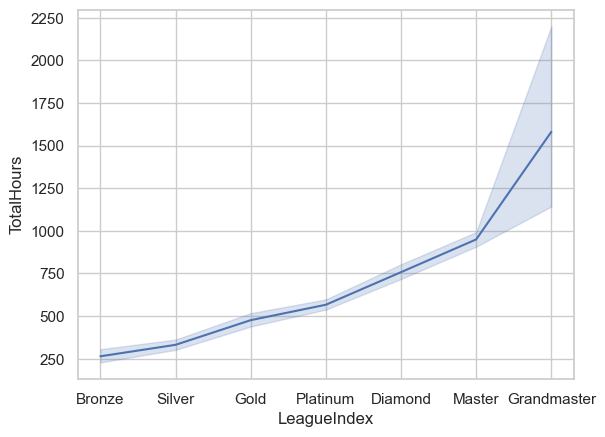

In [1252]:
lineplot = sns.lineplot(data=timeplayed_df, x="LeagueIndex", y="TotalHours")

lineplot.set_xticks(range(1, 8))
lineplot.set_xticklabels([
    "Bronze", "Silver", "Gold", "Platinum",
    "Diamond", "Master", "Grandmaster"
])

Le nombre d'heures de jeu nécéssaire pour monter en niveau est exponentiel.
A noter, le dataset date de 2013. Ce n'est pas représentatif de la situation en 2026.

## Question 3: Combien d'heures de jeu est-il nécéssaire pour construire des automatismes et être plus rapide au jeu ?

In [1253]:
speed_df = df[
    (df['TotalHours'] <= 1200)
]

speed_df = speed_df[["APM", "TotalHours"]]

speed_df['HoursBin'] = pd.cut(
    speed_df['TotalHours'],
    bins=[0,100,200,300,400,500,600,700,800,900,1000,1100,1200]
)

speed_df = speed_df.groupby('HoursBin')['APM'].mean().reset_index()
speed_df['HeureMoyenne'] = speed_df['HoursBin'].apply(lambda x: x.mid)

speed_df

,HoursBin,APM,HeureMoyenne
0,"(0, 100]",78.151986,50.0
1,"(100, 200]",94.187233,150.0
2,"(200, 300]",99.672595,250.0
3,"(300, 400]",107.185623,350.0
4,"(400, 500]",111.988781,450.0
5,"(500, 600]",116.859218,550.0
6,"(600, 700]",121.740058,650.0
7,"(700, 800]",126.605617,750.0
8,"(800, 900]",127.546891,850.0
9,"(900, 1000]",137.206324,950.0


<Axes: xlabel='HeureMoyenne', ylabel='APM'>

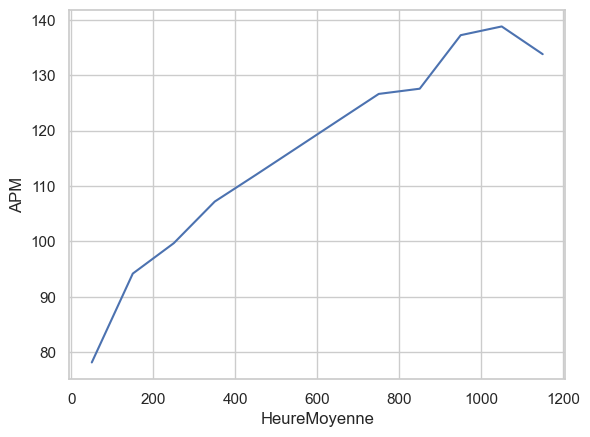

In [1254]:
sns.lineplot(speed_df, x='HeureMoyenne', y='APM')

L'APM moyen augmente en fonction du nombre d'heures jouées.

## Source
- https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0075129
- https://www.kaggle.com/datasets/danofer/skillcraft/data